# **RetailPulse: Retail Analytics, Customer Segmentation & Demand Forecasting**

# **Dataset Loading and Overview**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart style
sns.set_style("darkgrid")

# Load cleaned dataset
df = pd.read_csv("../data/processed/cleaned_retail.csv")

# Preview
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8,Wednesday


# **Data Quality Assessment**

In [33]:
print(df.shape)

print(df.info())

print(df.describe())

(397884, 14)
<class 'pandas.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  int64  
 1   StockCode    397884 non-null  str    
 2   Description  397884 non-null  str    
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  str    
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  str    
 8   TotalPrice   397884 non-null  float64
 9   Year         397884 non-null  int64  
 10  Month        397884 non-null  int64  
 11  Day          397884 non-null  int64  
 12  Hour         397884 non-null  int64  
 13  DayName      397884 non-null  str    
dtypes: float64(3), int64(6), str(5)
memory usage: 69.5 MB
None
           InvoiceNo       Quantity      UnitPrice     CustomerID  \
count  397884.000000  397884.000000  397884.000000  397884.000000 

# ** Revenue Analysis**

In [34]:
total_revenue = df["TotalPrice"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8911407.904


# **Country-wise Revenue Analysis**

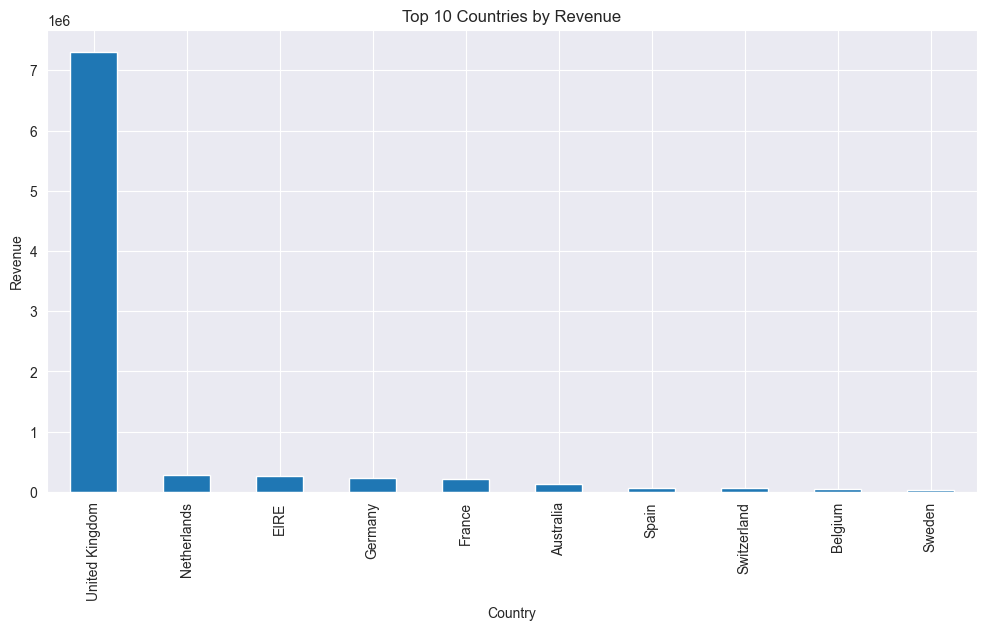

In [35]:
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["MonthYear"] = df["InvoiceDate"].dt.to_period("M")

# **Monthly Sales Trend Analysis**

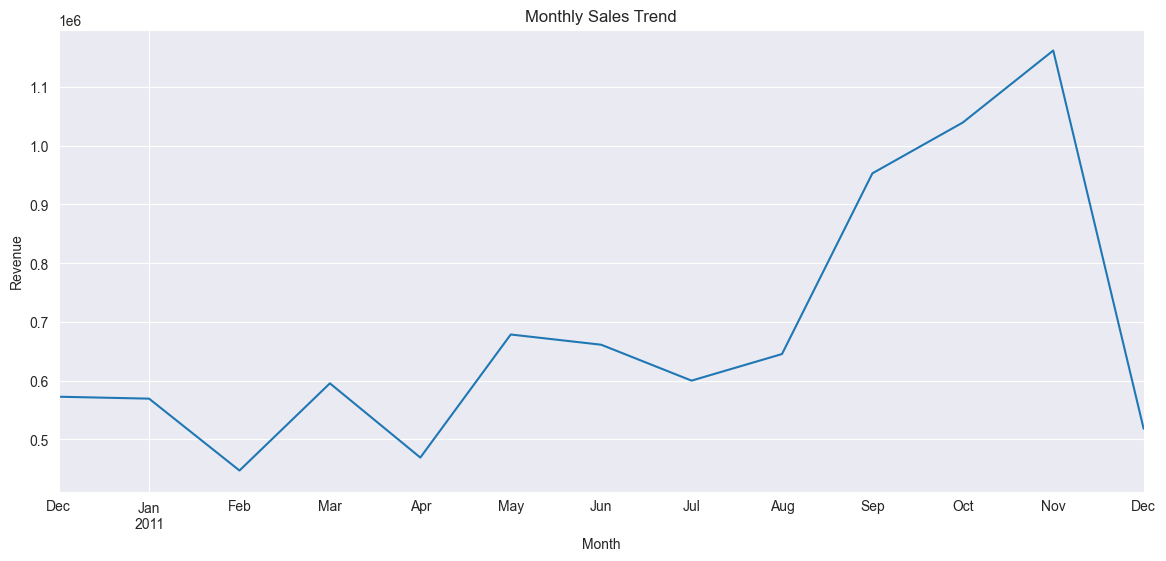

In [36]:
monthly_sales = df.groupby("MonthYear")["TotalPrice"].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

**#  Product Performance Analysis**

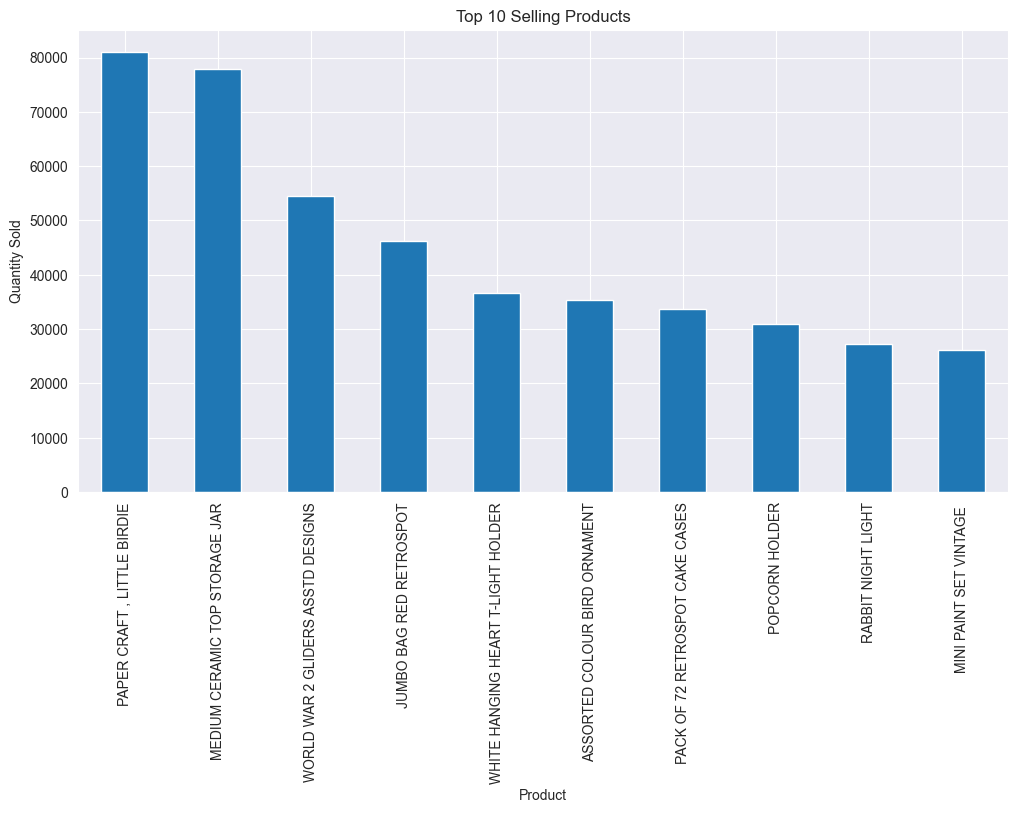

In [37]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

# **Customer Purchase Behaviour Analysis**

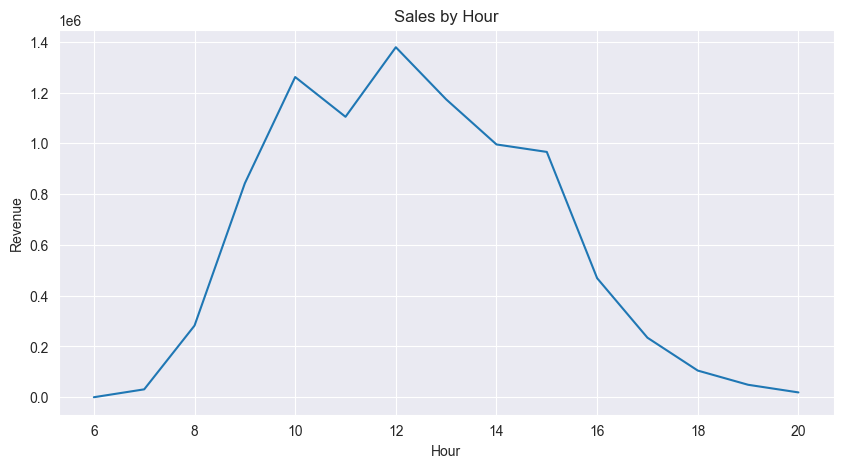

In [38]:
sales_by_hour = df.groupby("Hour")["TotalPrice"].sum()

plt.figure(figsize=(10,5))

sales_by_hour.plot()

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

# **RFM Analysis (Recency, Frequency, Monetary)**

In [39]:
# Convert InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Preview
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [40]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,91.720609,2054.266460
std,100.014169,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,307.415000
50%,51.000000,41.000000,674.485000
75%,142.000000,100.000000,1661.740000
max,374.000000,7847.000000,280206.020000


# **Customer Segmentation using K-Means Clustering**

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [42]:
# Scale features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# KMeans model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Create clusters
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Preview
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,1
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,3


# **VISUALIZATION**

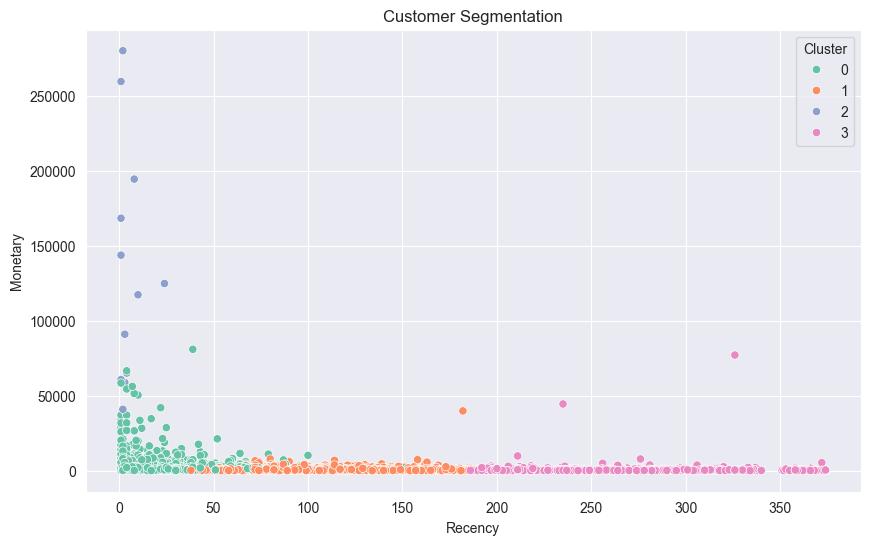

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation")

plt.show()

In [44]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,20.990788,135.285122,2645.818172
1,98.218703,37.719457,773.877083
2,4.692308,2565.307692,126118.310000
3,272.407005,25.138889,605.842525


# **NAME CLUSTERS**

In [45]:
cluster_names = {
    0: "VIP",
    1: "Loyal",
    2: "Lost",
    3: "Regular"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular
12347.0,2,182,4310.00,0,VIP
12348.0,75,31,1797.24,1,Loyal
12349.0,19,73,1757.55,0,VIP
12350.0,310,17,334.40,3,Regular


# **Segment Distribution Analysis**

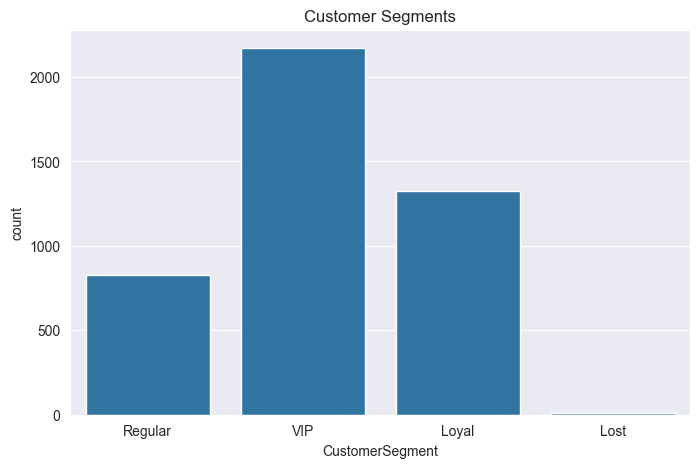

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="CustomerSegment"
)

plt.title("Customer Segments")

plt.show()

# **# Demand Forecasting**

In [47]:
from prophet import Prophet

# **CREATE DAILY SALES DATA**

In [48]:
daily_sales = df.groupby("InvoiceDate")["TotalPrice"].sum().reset_index()

daily_sales.columns = ["ds", "y"]

daily_sales.head()

,ds,y
0,2010-12-01 08:26:00,139.12
1,2010-12-01 08:28:00,22.20
2,2010-12-01 08:34:00,348.78
3,2010-12-01 08:35:00,17.85
4,2010-12-01 08:45:00,855.86


# **TRAIN MODEL**

In [49]:
model = Prophet()

model.fit(daily_sales)

18:24:38 - cmdstanpy - INFO - Chain [1] start processing
18:24:42 - cmdstanpy - INFO - Chain [1] done processing


# **Forecast Results and Trend Analysis**

In [50]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01 08:26:00,577.512289,-1790.326538,2649.380932,577.512289,577.512289,-88.726060,-88.726060,-88.726060,-120.793525,-120.793525,-120.793525,32.067465,32.067465,32.067465,0.0,0.0,0.0,488.786229
1,2010-12-01 08:28:00,577.518532,-1579.772477,2714.570907,577.518532,577.518532,-88.099813,-88.099813,-88.099813,-120.006366,-120.006366,-120.006366,31.906554,31.906554,31.906554,0.0,0.0,0.0,489.418719
2,2010-12-01 08:34:00,577.537260,-1715.663993,2781.584347,577.537260,577.537260,-85.890733,-85.890733,-85.890733,-117.315108,-117.315108,-117.315108,31.424375,31.424375,31.424375,0.0,0.0,0.0,491.646526
3,2010-12-01 08:35:00,577.540381,-1706.187016,2554.930382,577.540381,577.540381,-85.481515,-85.481515,-85.481515,-116.825610,-116.825610,-116.825610,31.344095,31.344095,31.344095,0.0,0.0,0.0,492.058866
4,2010-12-01 08:45:00,577.571594,-1691.546622,2680.951699,577.571594,577.571594,-80.950244,-80.950244,-80.950244,-111.492937,-111.492937,-111.492937,30.542692,30.542692,30.542692,0.0,0.0,0.0,496.621350


# **VISUALIZE FORECAST**

In [ ]:
fig = model.plot(forecast)
plt.show()

# **`Key Insights**




- United Kingdom generated the highest revenue.
- Peak sales occurred during specific business hours.
- VIP customers contributed significantly to revenue.
- Lost customers present re-engagement opportunities.
- Forecast indicates continued revenue growth over the next 30 days.